# Tarefa 5

In [1]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, datasets
from transformers import CLIPModel, CLIPProcessor
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import os

# Configuración inicial

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"


if os.path.exists("./tiny-imagenet-200/"):
    print("Xa existe o directorio :)")
    train = "./tiny-imagenet-200/train/"
elif not os.path.exists("./IMagenet/"):
    print("Clonando Tiny ImageNet desde GitHub... :)")
    os.system("git clone https://github.com/seshuad/IMagenet.git")
    print("Clonado exitosamente")
    train = "./IMagenet/tiny-imagenet-200/train/"
else:
    train = "./IMagenet/tiny-imagenet-200/train/"


# Transformacións estándar de CLIP
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.481, 0.457, 0.408], std=[0.268, 0.261, 0.275])
])

full_dataset = datasets.ImageFolder(root=train, transform=transform)
# Usamos un subset para que a indexación sexa rápida nesta tarefa
n_clases_avaliar = 20
indices = [idx for idx, (_, label) in enumerate(full_dataset.samples) if label < n_clases_avaliar]
subset_dataset = Subset(full_dataset, indices)
loader = DataLoader(subset_dataset, batch_size=64, shuffle=False)


Clonando Tiny ImageNet desde GitHub... :)
Clonado exitosamente


# Carga e indexación

In [3]:
print(f"Cargando CLIP en {device}...")
model_clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor_clip = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

Cargando CLIP en cuda...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [4]:
def index_dataset_with_clip(model, dataloader):
    features_list = []
    labels_list = []
    model.eval()
    with torch.no_grad():
        for imgs, labels in tqdm(dataloader):
            imgs = imgs.to(device)

            # Extraer características
            outputs = model.get_image_features(pixel_values=imgs)

            # ERRO FIX: Se 'outputs' é un obxecto e non un tensor, extraemos o tensor
            if hasattr(outputs, "pooler_output"):
                img_features = outputs.pooler_output
            else:
                img_features = outputs

            # Agora que é un tensor, xa podemos normalizar
            img_features = F.normalize(img_features, p=2, dim=1)

            features_list.append(img_features.cpu())
            labels_list.append(labels)

    return torch.cat(features_list), torch.cat(labels_list)

print("\nIndexando o dataset con CLIP (Imaxes)...")
feats_visual, labels_all = index_dataset_with_clip(model_clip, loader)


Indexando o dataset con CLIP (Imaxes)...


100%|██████████| 157/157 [00:44<00:00,  3.52it/s]


# Búsqueda combinada

In [5]:
def combined_search(query_img_tensor, query_text, model, indexed_features, k=5, alpha=0.5): #alpha: peso da imaxe (0.5 = 50% imaxe, 50% texto)
    model.eval()
    with torch.no_grad():
        # Feature da imaxe de consulta
        img_q = query_img_tensor.unsqueeze(0).to(device) if len(query_img_tensor.shape)==3 else query_img_tensor.to(device)
        img_feat = model.get_image_features(pixel_values=img_q)

        img_feat = img_feat.pooler_output if hasattr(img_feat, "pooler_output") else img_feat # Solución erro
        img_feat = F.normalize(img_feat, p=2, dim=1)

        # Feature do texto
        text_inputs = processor_clip(text=[query_text], return_tensors="pt", padding=True).to(device)
        text_feat = model.get_text_features(**text_inputs)

        text_feat = text_feat.pooler_output if hasattr(text_feat, "pooler_output") else text_feat # Solución erro
        text_feat = F.normalize(text_feat, p=2, dim=1)

        # Fusión e re-normalización
        combined_feat = alpha * img_feat + (1 - alpha) * text_feat
        combined_feat = F.normalize(combined_feat, p=2, dim=1)

        # Similitude
        sims = torch.mm(combined_feat, indexed_features.t().to(device))
        values, indices = torch.topk(sims, k)
        return indices[0].cpu().numpy(), values[0].cpu().numpy()


# Avaliación

In [8]:
def evaluate_modes(model, dataset, indexed_features, labels, n_tests=20):
    p_img, p_text, p_comb = 0, 0, 0
    print(f"\nRealizando análise comparativa en {n_tests} mostras...")

    for i in range(n_tests):
        idx = np.random.randint(len(dataset))
        img, label = dataset[idx]

        # Para o texto, usamos o nome da carpeta como prompt simple
        folder_id = dataset.dataset.classes[label]
        human_label = class_map.get(folder_id, folder_id)
        text_prompt = f"a photo of a {human_label}"

        # Test 1: Só imaxe
        res_i, _ = combined_search(img, "", model, indexed_features, alpha=1.0)
        p_img += (labels[res_i] == label).float().mean().item()

        # Test 2: Só texto
        res_t, _ = combined_search(torch.zeros_like(img), text_prompt, model, indexed_features, alpha=0.0)
        p_text += (labels[res_t] == label).float().mean().item()

        # Test 3: Combinada
        res_c, _ = combined_search(img, text_prompt, model, indexed_features, alpha=0.5)
        p_comb += (labels[res_c] == label).float().mean().item()

    print("-" * 30)
    print(f"Precision@5 Só Imaxe: {p_img/n_tests:.4f}")
    print(f"Precision@5 Só Texto: {p_text/n_tests:.4f}")
    print(f"Precision@5 Combinada: {p_comb/n_tests:.4f}")
    print("-" * 30)

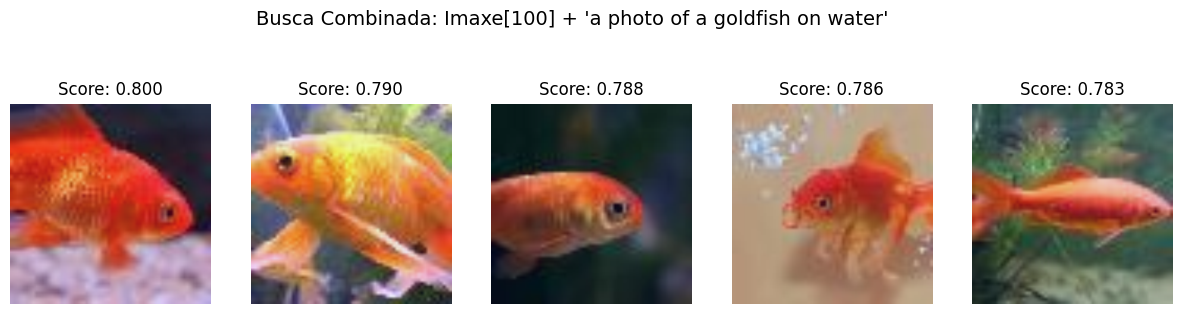


Realizando análise comparativa en 20 mostras...
------------------------------
Precision@5 Só Imaxe: 0.7200
Precision@5 Só Texto: 0.9800
Precision@5 Combinada: 0.8900
------------------------------


In [11]:
# Cargar o mapeo de nomes reais
class_map = {}
with open("/content/IMagenet/tiny-imagenet-200/words.txt", "r") as f:
    for line in f:
        parts = line.strip().split("\t")
        class_map[parts[0]] = parts[1].split(",")[0] # Collemos o primeiro sinónimo
query_idx = 100
img_q, label_q = subset_dataset[query_idx]
prompt_q = "a photo of a goldfish on water"

indices_res, scores_res = combined_search(img_q, prompt_q, model_clip, feats_visual, k=5)

# Mostrar resultados
plt.figure(figsize=(15, 4))
plt.suptitle(f"Busca Combinada: Imaxe[{query_idx}] + '{prompt_q}'", fontsize=14)
for i, idx in enumerate(indices_res):
    img, _ = subset_dataset[idx]
    img = img.permute(1,2,0).numpy() * 0.25 + 0.45 # Desnormalizar
    plt.subplot(1, 5, i+1)
    plt.imshow(np.clip(img, 0, 1))
    plt.title(f"Score: {scores_res[i]:.3f}")
    plt.axis('off')
plt.show()

# Lanzar avaliación comparativa
evaluate_modes(model_clip, subset_dataset, feats_visual, labels_all)